In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

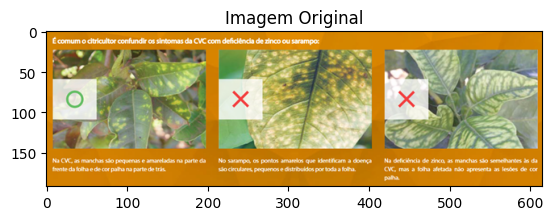

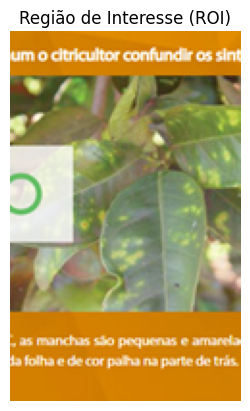

Resultado da análise: CVC


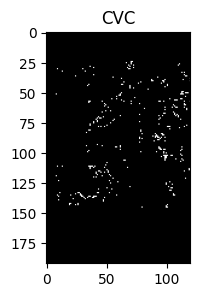

In [ ]:
# 1. Carrega e converte para RGB
imagem = cv2.imread('/content/drive/MyDrive/imagens/folhas_citros.png')
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# 2. Mostra a imagem original
plt.imshow(imagem)
plt.title('Imagem Original')
plt.show()

# 3. Seleciona a ROI
roi = imagem[0:200, 30:150]  # ajuste as coordenadas se quiser
plt.imshow(roi)
plt.title('Região de Interesse (ROI)')
plt.axis('off')
plt.show()

# 4. Converte para HSV
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)

# 5. Define faixas de cores para cada patologia
# CVC - manchas amareladas
lower_cvc = np.array([20, 50, 150])
upper_cvc = np.array([219, 230, 152])



# 6. Cria máscaras
mask_cvc = cv2.inRange(roi_hsv, lower_cvc, upper_cvc)


# 7. Conta os pixels
area_cvc = cv2.countNonZero(mask_cvc)




print(f"Resultado da análise: CVC")

# 9. Exibe máscaras
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.imshow(mask_cvc, cmap='gray')
plt.title('CVC')


plt.show()




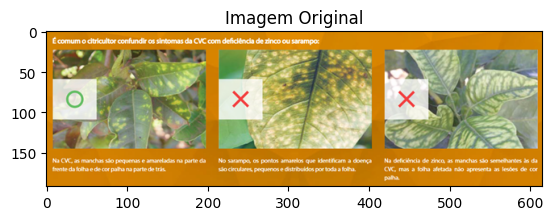

Tamanho da imagem: (192, 615, 3)


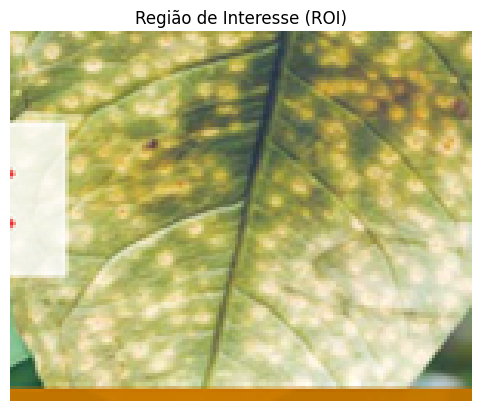

Resultado da análise: Sarampo


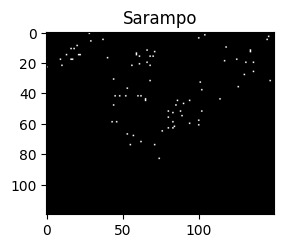

In [ ]:
# 1. Carrega e converte para RGB
imagem = cv2.imread('/content/drive/MyDrive/imagens/folhas_citros.png')
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# 2. Mostra a imagem original
plt.imshow(imagem)
plt.title('Imagem Original')
plt.show()

# 3. Seleciona a ROI
# Carrega a imagem
imagem = cv2.imread('/content/drive/MyDrive/imagens/folhas_citros.png')

# Verifique o tamanho da imagem
print(f"Tamanho da imagem: {imagem.shape}")

# Converte para RGB (matplotlib espera RGB, OpenCV usa BGR)
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# Verifique se as coordenadas da ROI estão dentro da imagem
# As coordenadas precisam ser dentro dos limites da imagem
roi = imagem_rgb[30:150, 250:400]

# Exibe a ROI
plt.imshow(roi)
plt.title('Região de Interesse (ROI)')
plt.axis('off')
plt.show()

# 4. Converte para HSV
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)


# Sarampo - manchas escuras/marrons
lower_sarampo = np.array([20, 50, 150])
upper_sarampo = np.array([220, 232, 150])



# 6. Cria máscaras

mask_sarampo = cv2.inRange(roi_hsv, lower_sarampo, upper_sarampo)


# 7. Conta os pixels

area_sarampo = cv2.countNonZero(mask_sarampo)


print(f"Resultado da análise: Sarampo")

# 9. Exibe máscaras
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.imshow(mask_sarampo, cmap='gray')
plt.title('Sarampo')



plt.show()

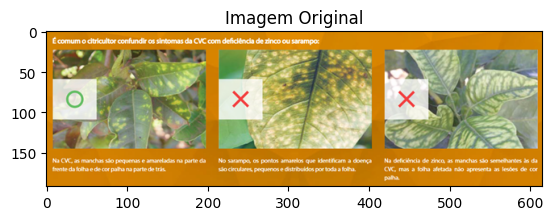

Tamanho da imagem: (192, 615, 3)


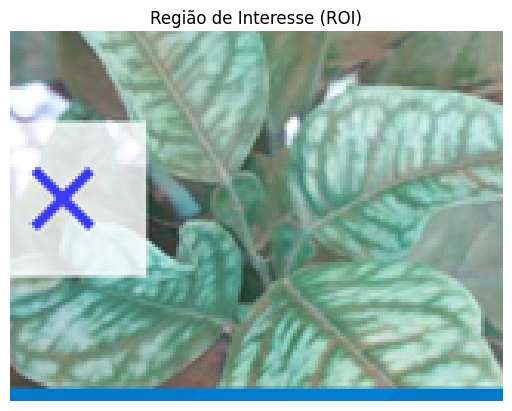

Resultado da análise: Deficiência de Zinco


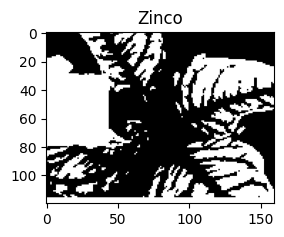

In [ ]:
imagem = cv2.imread('/content/drive/MyDrive/imagens/folhas_citros.png')
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# 2. Mostra a imagem original
plt.imshow(imagem)
plt.title('Imagem Original')
plt.show()

# Verifique o tamanho da imagem
print(f"Tamanho da imagem: {imagem.shape}")

# Converte para RGB (matplotlib espera RGB, OpenCV usa BGR)
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# Verifique se as coordenadas da ROI estão dentro da imagem
# As coordenadas precisam ser dentro dos limites da imagem
roi = imagem_rgb[30:150, 430:590]

# Exibe a ROI
plt.imshow(roi)
plt.title('Região de Interesse (ROI)')
plt.axis('off')
plt.show()

# 4. Converte para HSV
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)


# Zinco - áreas muito claras
lower_zinco = np.array([0, 0, 180])
upper_zinco = np.array([255, 255, 255])

# 6. Cria máscaras

mask_zinco = cv2.inRange(roi_hsv, lower_zinco, upper_zinco)

# 7. Conta os pixels

area_zinco = cv2.countNonZero(mask_zinco)


print(f"Resultado da análise: Deficiência de Zinco")

# 9. Exibe máscaras
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.imshow(mask_zinco, cmap='gray')
plt.title('Zinco')



plt.show()

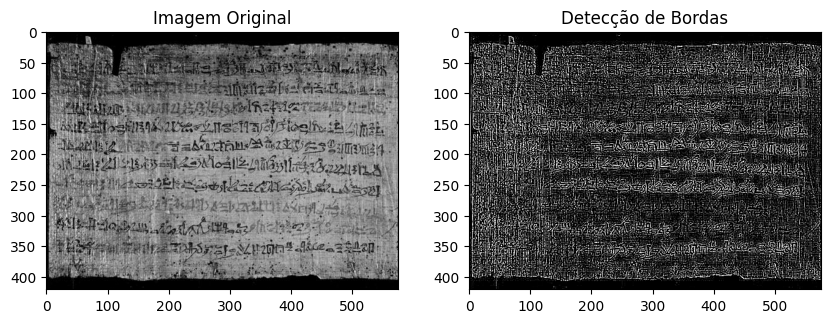

In [ ]:
imagem = cv2.imread('/content/drive/MyDrive/imagens/papiro_Leiden.jpg', cv2.IMREAD_GRAYSCALE)


kernel = np.array([[-1,-1,-1],
                   [-1,8,-1],
                   [-1,-1,-1]])

img_filt = cv2.filter2D(imagem, -1, kernel)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(imagem, cmap='gray'), plt.title('Imagem Original')
plt.subplot(122), plt.imshow(img_filt, cmap='gray'), plt.title('Detecção de Bordas')
plt.show()

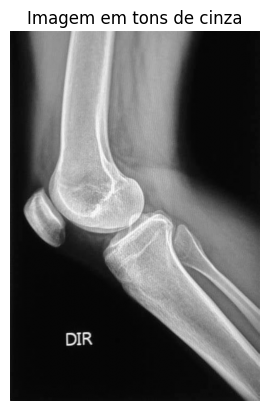

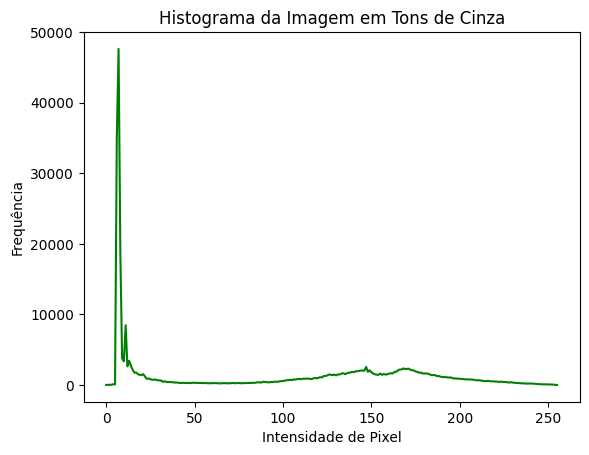

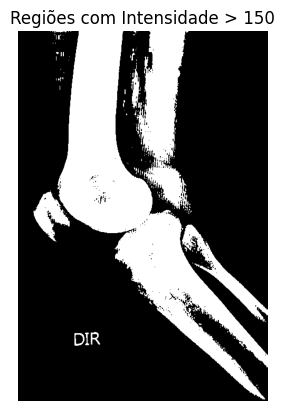

In [ ]:
imagem = cv2.imread('/content/drive/MyDrive/imagens/raiox-joelho.jpg')


imagem_gray = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# Exibe a imagem em escala de cinza
plt.imshow(imagem_gray, cmap='gray')
plt.title('Imagem em tons de cinza')
plt.axis('off')
plt.show()

# Histograma
hist = cv2.calcHist([imagem_gray], [0], None, [256], [0, 256])
plt.plot(hist, color='green')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.title('Histograma da Imagem em Tons de Cinza')
plt.show()

# Thresholding - destaque das regiões mais claras (ossos)
threshold_val = 150
_,imagem_thresh = cv2.threshold(imagem_gray, threshold_val, 255, cv2.THRESH_BINARY)

# Normalização (já está 0-255, mas vamos garantir)
imagem_norm = cv2.normalize(imagem_thresh, None, 0, 255, cv2.NORM_MINMAX)

# Exibe o resultado
plt.imshow(imagem_norm, cmap='gray')
plt.title(f'Regiões com Intensidade > {threshold_val}')
plt.axis('off')
plt.show()